# 07. Mean radiant temperature

Mean radiant temperature is radiation as one number: the radiation a body actually catches,
from every direction, written back as a temperature. 

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
CELL = CONFIG["cell_size"]
DATE = CONFIG["date"]
LAT, LON = CONFIG["lat"], CONFIG["lon"]

# The same 1500 x 1500 window over the CBD as 03 and 06. Full grid once, at the end.
half = int(3000 / CELL / 2)
CROP = np.s_[H // 2 - half:H // 2 + half, W // 2 - half:W // 2 + half]

HOURS = list(range(6, 21))
print(f"grid  {W} x {H}   crop  {2 * half} x {2 * half} cells   {DATE}")

grid  2438 x 2485   crop  1500 x 1500 cells   2026-01-27


In [2]:
shade = {h: np.load(f"out/rasters/shade_{h:02d}.npy")[CROP] for h in HOURS}   # True = in shadow
tsurf = {h: np.load(f"out/rasters/tsurf_{h:02d}.npy")[CROP] for h in HOURS}   # 06's ground, degC
svf   = np.load("out/rasters/svf_veg.npy")[CROP]
mat   = np.load("out/rasters/material_id.npy")[CROP]
dsm   = np.load("out/rasters/dsm_buildings.npy")[CROP]

props   = json.load(open("out/material_props.json"))
CLASSES = props["classes"]
ALBEDO  = np.array([props["props"][c]["albedo"] for c in CLASSES])
EMIS    = np.array([props["props"][c]["emis"]   for c in CLASSES])

w = pd.DataFrame(json.load(open(f"data/weather_{DATE}.json"))["hourly"])
w.index = pd.to_datetime(w.pop("time")).dt.hour
w["wind_ms"] = w["wind_speed_10m"] / 3.6

In [3]:
from pvlib.solarposition import get_solarposition

times = pd.to_datetime([f"{DATE} {h:02d}:00" for h in HOURS]).tz_localize("Australia/Melbourne")
ELEV = dict(zip(HOURS, get_solarposition(times, LAT, LON)["apparent_elevation"].values))

print(f"{'hour':>4s} {'air':>6s} {'sun elev':>9s} {'direct':>7s} {'diffuse':>8s}")
for h in HOURS:
    print(f"{h:4d} {w.loc[h, 'temperature_2m']:6.1f} {ELEV[h]:8.1f}d"
          f" {w.loc[h, 'direct_radiation']:7.0f} {w.loc[h, 'diffuse_radiation']:8.0f}")

hour    air  sun elev  direct  diffuse
   6   15.7     -5.7d       4        6
   7   17.6      5.2d      91       49
   8   21.3     16.5d     270       77
   9   27.8     28.3d     465       92
  10   33.2     40.1d     643      102
  11   36.8     51.6d     780      108
  12   39.0     62.0d     867      111
  13   40.8     69.4d     896      113
  14   42.4     69.8d     868      111
  15   43.3     62.9d     780      107
  16   43.4     52.6d     608      121
  17   43.4     41.1d     428      106
  18   42.7     29.3d     221       99
  19   40.3     17.6d      85       52
  20   38.7      6.2d       4        9


## What MRT is

MRT is the answer to: *what would an oven have to be set to, to cook you at this rate?*

On the street the heat comes at you from things at wildly different temperatures — 68 °C road
underfoot, 35 °C walls beside you, the sun overhead, a cold sky above that. Too many numbers to
carry around. So swap the street for a plain box where everything is the **same** temperature,
and turn that box up until the body feels the same. That one setting is the MRT.

Air temperature cannot do this job. It is 42 °C in the sun and 42 °C in the shade. MRT is 68
and 39.

### Seven streams

A standing body is lit from all sides. Sunlight arrives four ways and glow arrives three, and
each one is scaled by how much of that thing the body can see.

| stream | where it comes from |
|---|---|
| $K_{dir}$ | the beam, if the cell is sunlit |
| $K_{dif}$ | the rest of the sky, through the SVF |
| $K_{ref,g}$ | sun bouncing back off the ground |
| $K_{ref,w}$ | sun bouncing off walls — the crudest term, and the smallest |
| $L_{sky}$ | the sky glowing, through the SVF |
| $L_{wall}$ | walls glowing, through $1-\text{SVF}$ |
| $L_{gnd}$ | the ground glowing, at 06's $T_s$ |

All seven in W/m². The three big ones are $K_{dir}$, $L_{gnd}$ and $L_{sky}$; the rest are
trim.

In [4]:
from pyproj import Transformer

to_m = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)
R0, C0 = CROP[0].start, CROP[1].start

def cell_of(lon, lat):
    x, y = to_m.transform(lon, lat)
    return (int((CONFIG["grid"]["maxy"] - y) / CELL) - R0,
            int((x - CONFIG["grid"]["minx"]) / CELL) - C0)

SPOTS = {"open road":   cell_of(144.97043, -37.81696),
         "shaded road": cell_of(144.96670, -37.81319),
         "park lawn":   cell_of(144.97238, -37.82049),
         "laneway":     cell_of(144.96541, -37.81279)}

HOUR = 14

print(f"at {HOUR}:00, air {w.loc[HOUR, 'temperature_2m']:.1f} C\n")
print(f"{'':13s} {'surface':10s} {'SVF':>6s} {'sun':>9s} {'ground Ts':>10s}")
for name, (r, c) in SPOTS.items():
    print(f"{name:13s} {CLASSES[mat[r, c]]:10s} {svf[r, c]:6.2f}"
          f" {'shaded' if shade[HOUR][r, c] else 'sunlit':>9s} {tsurf[HOUR][r, c]:9.1f}C")

at 14:00, air 42.4 C

              surface       SVF       sun  ground Ts
open road     asphalt      0.82    sunlit      67.9C
shaded road   asphalt      0.49    shaded      35.8C
park lawn     grass        0.89    sunlit      56.0C
laneway       bluestone    0.03    shaded      33.3C


## Sunlight, four ways

$$K = \underbrace{K_{dir}}_{\text{the beam}} + \underbrace{K_{dif}}_{\text{the sky}}
   + \underbrace{K_{ref,g}}_{\text{off the ground}} + \underbrace{K_{ref,w}}_{\text{off walls}}$$

Two things need care.

**A body is not flat.** The weather file gives the beam landing on flat ground. A standing
person is an upright shape, so at noon the sun mostly misses them and late in the day it hits
them side-on. That is $f_p$ — the fraction of a body the sun actually sees, from the sun's angle.

**Half a body looks up, half looks down.** So sky terms carry a 0.5 and ground terms carry a 0.5.

In [5]:
SIGMA = 5.670e-8      # Stefan-Boltzmann, W/m2K4
A_SW  = 0.70          # how much shortwave a clothed body absorbs -- ISO 7726
EPS_P = 0.97          # how well skin and clothing glow in infrared
A_WALL, EPS_WALL = 0.20, 0.90     # a brick-and-glass facade

def f_p(el):
    """Fraction of a standing body the beam sees, at solar elevation el degrees. Fanger 1970."""
    el = np.maximum(el, 0)
    return 0.308 * np.cos(np.radians(el * (0.998 - el ** 2 / 50000)))

for h in (8, 11, 14, 17, 19):
    print(f"{h:02d}:00   sun {ELEV[h]:5.1f}deg   f_p {f_p(ELEV[h]):.2f}")

08:00   sun  16.5deg   f_p 0.30
11:00   sun  51.6deg   f_p 0.20
14:00   sun  69.8deg   f_p 0.14
17:00   sun  41.1deg   f_p 0.24
19:00   sun  17.6deg   f_p 0.29


The beam also has to be turned side-on before $f_p$ can use it. `direct_radiation` is what lands
on flat ground, which at a low sun is a strong beam smeared thin; dividing by $\sin(\text{elev})$
gives the beam its own strength back, along its own direction.

$$K_{dir} = \frac{\text{direct}}{\sin(\text{elev})}\cdot f_p\cdot(\text{sunlit})$$

In [6]:
hw = w.loc[HOUR]
Ta = hw["temperature_2m"]
K_flat, K_dif = hw["direct_radiation"], hw["diffuse_radiation"]

beam = K_flat / np.sin(np.radians(ELEV[HOUR]))        # flat ground -> along the beam
print(f"{HOUR}:00   sun {ELEV[HOUR]:.0f}deg   {K_flat:.0f} W/m2 on the ground"
      f"  ->  {beam:.0f} W/m2 in the beam,   f_p {f_p(ELEV[HOUR]):.2f}\n")

print(f"{'':13s} {'K_dir':>7s} {'K_dif':>7s} {'K_ref_g':>8s} {'K_ref_w':>8s}")
for name, (r, c) in SPOTS.items():
    sunlit, sky = ~shade[HOUR][r, c], svf[r, c]
    down = K_flat * sunlit + K_dif * sky              # what lands on the ground here
    print(f"{name:13s} {beam * f_p(ELEV[HOUR]) * sunlit:7.0f} {0.5 * K_dif * sky:7.0f}"
          f" {0.5 * ALBEDO[mat[r, c]] * down:8.0f}"
          f" {0.5 * A_WALL * (1 - sky) * (K_flat + K_dif):8.0f}")

14:00   sun 70deg   868 W/m2 on the ground  ->  925 W/m2 in the beam,   f_p 0.14

                K_dir   K_dif  K_ref_g  K_ref_w
open road         130      45       58       18
shaded road         0      27        3       50
park lawn         130      49      111       11
laneway             0       2        0       95


## Glow, three ways

Everything warm glows in infrared at $\varepsilon\sigma T^4$ — the same term 06 used. A body is
surrounded by three glowing things, and the SVF decides how much of each it sees:

$$L = \underbrace{0.5\,\text{SVF}\,\varepsilon_{sky}\sigma T_a^4}_{\text{sky}}
    + \underbrace{0.5\,(1-\text{SVF})\,\varepsilon_{w}\sigma T_a^4}_{\text{walls}}
    + \underbrace{0.5\,\varepsilon_{g}\sigma T_s^4}_{\text{ground}}$$

The ground term is where 06 pays off: $T_s$ is its answer, and a 68 °C road throws far more at
you than a 42 °C one. The sky is the only thing here colder than the air, which is why open sky
is worth a lot at night and very little at 2 pm.

In [7]:
Ta_K = Ta + 273.15
e = 6.112 * np.exp(17.62 * Ta / (243.12 + Ta)) * hw["relative_humidity_2m"] / 100
eps_clear = 1.24 * (e / Ta_K) ** (1 / 7)                       # Brutsaert 1975, as in 06
eps_sky = eps_clear + (1 - eps_clear) * hw["cloud_cover"] / 100

print(f"sky eps {eps_sky:.2f}   air {Ta:.1f} C\n")
print(f"{'':13s} {'SVF':>6s} {'L_sky':>7s} {'L_wall':>7s} {'L_gnd':>7s}")
for name, (r, c) in SPOTS.items():
    sky, Ts = svf[r, c], tsurf[HOUR][r, c]
    print(f"{name:13s} {sky:6.2f} {0.5 * sky * eps_sky * SIGMA * Ta_K ** 4:7.0f}"
          f" {0.5 * (1 - sky) * EPS_WALL * SIGMA * Ta_K ** 4:7.0f}"
          f" {0.5 * EMIS[mat[r, c]] * SIGMA * (Ts + 273.15) ** 4:7.0f}")

sky eps 0.77   air 42.4 C

                 SVF   L_sky  L_wall   L_gnd
open road       0.82     178      46     361
shaded road     0.49     106     129     243
park lawn       0.89     194      28     323
laneway         0.03       7     244     238


## Adding up, and going back to a temperature

A body soaks up 70% of the sunlight that hits it and nearly all of the infrared:

$$S = 0.70\sum K \;+\; 0.97\sum L$$

$S$ is in W/m², and nobody wants a heat warning in W/m². So run $\varepsilon\sigma T^4$
backwards — the temperature a body would have to be surrounded by to receive exactly $S$:

$$T_{mrt} = \sqrt[4]{\frac{S}{0.97\,\sigma}} - 273.15$$

That is the whole notebook, in one function.

In [8]:
NAMES = ["K_dir", "K_dif", "K_ref_g", "K_ref_w", "L_sky", "L_wall", "L_gnd"]

def streams(hour, sunlit, sky, m, Ts):
    """The seven streams, W/m2. Scalars or whole rasters, same code."""
    hw = w.loc[hour]
    Ta = hw["temperature_2m"]
    Ta_K = Ta + 273.15
    el = ELEV[hour]

    e = 6.112 * np.exp(17.62 * Ta / (243.12 + Ta)) * hw["relative_humidity_2m"] / 100
    eps_clear = 1.24 * (e / Ta_K) ** (1 / 7)
    eps_sky = eps_clear + (1 - eps_clear) * hw["cloud_cover"] / 100

    K_flat, K_dif = hw["direct_radiation"], hw["diffuse_radiation"]
    beam = K_flat / max(np.sin(np.radians(max(el, 0.1))), 0.05)   # floored: the sun is on the horizon
    down = K_flat * sunlit + K_dif * sky

    return (beam * f_p(el) * sunlit,
            0.5 * K_dif * sky,
            0.5 * ALBEDO[m] * down,
            0.5 * A_WALL * (1 - sky) * (K_flat + K_dif),
            0.5 * sky * eps_sky * SIGMA * Ta_K ** 4,
            0.5 * (1 - sky) * EPS_WALL * SIGMA * Ta_K ** 4,
            0.5 * EMIS[m] * SIGMA * (Ts + 273.15) ** 4)

def mrt(hour, sunlit, sky, m, Ts):
    K = streams(hour, sunlit, sky, m, Ts)
    S = A_SW * sum(K[:4]) + EPS_P * sum(K[4:])
    return (S / (EPS_P * SIGMA)) ** 0.25 - 273.15

In [9]:
print(f"at {HOUR}:00, air is {Ta:.1f} C\n")
print(f"{'':13s}" + "".join(f"{n:>8s}" for n in NAMES) + f"{'MRT':>9s}")
for name, (r, c) in SPOTS.items():
    args = (HOUR, ~shade[HOUR][r, c], svf[r, c], mat[r, c], tsurf[HOUR][r, c])
    print(f"{name:13s}" + "".join(f"{x:8.0f}" for x in streams(*args)) + f"{mrt(*args):8.1f}C")

at 14:00, air is 42.4 C

                K_dir   K_dif K_ref_g K_ref_w   L_sky  L_wall   L_gnd      MRT
open road         130      45      58      18     178      46     361    67.7C
shaded road         0      27       3      50     106     129     243    38.8C
park lawn         130      49     111      11     194      28     323    67.3C
laneway             0       2       0      95       7     244     238    42.0C


Two things fall out of that table.

The laneway gets **no sun at all** and still lands near air temperature — 3% sky means walls and
floor glowing at it from every side, with no cold sky to lose anything to.

The lawn is nearly as bad as the road, because it is in the same sun. Its ground glow is lower
by 40 W/m², and that is all the good a cool surface does you while the beam is on you. For MRT,
shade beats material.

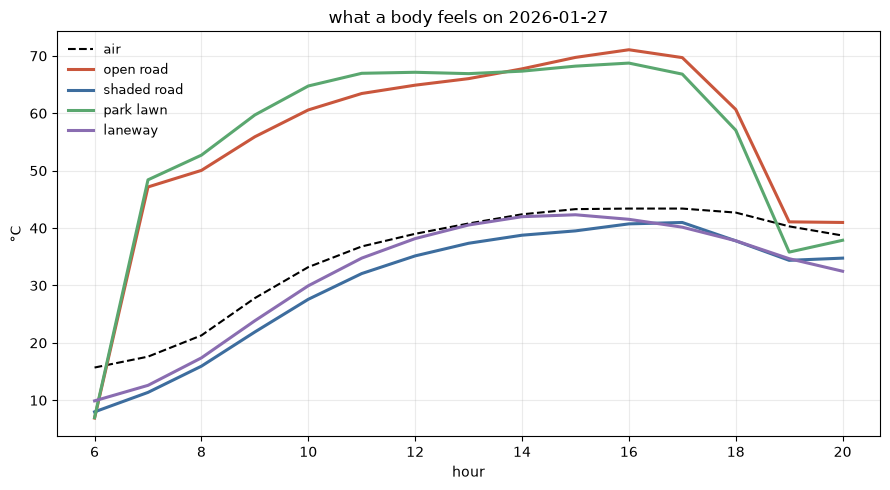

In [10]:
day = {name: [mrt(h, ~shade[h][r, c], svf[r, c], mat[r, c], tsurf[h][r, c]) for h in HOURS]
       for name, (r, c) in SPOTS.items()}

COLOURS = {"open road": "#c9563c", "shaded road": "#3d6d9e",
           "park lawn": "#5aa76f", "laneway": "#8a6db1"}

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(HOURS, [w.loc[h, "temperature_2m"] for h in HOURS], "k--", lw=1.5, label="air")
for name, series in day.items():
    ax.plot(HOURS, series, color=COLOURS[name], lw=2.2, label=name)

ax.set_xlabel("hour"); ax.set_ylabel("°C")
ax.set_xticks(HOURS[::2]); ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
ax.set_title(f"what a body feels on {DATE}")
fig.tight_layout()

The sunlit pair run about 25 °C above the air all afternoon. The shaded pair run *below* it. Red
line and blue line are the same road twenty metres apart, and that gap is the reason this
project exists.

The steps are the shade maps switching a cell on and off on the hour — 01 gives one raster per
hour, so the beam arrives whole or not at all.

## Every cell

`streams()` takes arrays as happily as numbers, so nothing changes but what goes in.

In [11]:
mrt_crop = {h: mrt(h, ~shade[h], svf, mat, tsurf[h]).astype(np.float32) for h in HOURS}

ground = dsm <= 0                       # roofs are not a place anyone stands
print(f"{'hour':>4s} {'air':>6s} {'mean MRT':>9s} {'hottest':>8s}")
for h in HOURS:
    print(f"{h:4d} {w.loc[h, 'temperature_2m']:6.1f} {mrt_crop[h][ground].mean():9.1f}"
          f" {mrt_crop[h][ground].max():8.1f}")

hour    air  mean MRT  hottest
   6   15.7       7.8     11.3
   7   17.6      15.5     49.2
   8   21.3      25.1     53.7
   9   27.8      35.6     61.5
  10   33.2      43.5     67.5
  11   36.8      50.0     70.6
  12   39.0      52.9     72.2
  13   40.8      55.6     73.3
  14   42.4      58.3     74.6
  15   43.3      57.6     75.2
  16   43.4      57.0     73.3
  17   43.4      54.8     70.4
  18   42.7      47.3     61.1
  19   40.3      39.5     51.3
  20   38.7      37.1     44.5


### The seven, as maps

Each stream on its own, one colour scale. Three of them are maps you have already seen: $K_{dir}$
is 01's shadows, $L_{gnd}$ is 06's surface temperature, $L_{sky}$ is 03's sky view factor. MRT is
those three stacked, plus trim.

Text(0.5, 0.98, 'the seven streams at 14:00, W/m² — same scale')

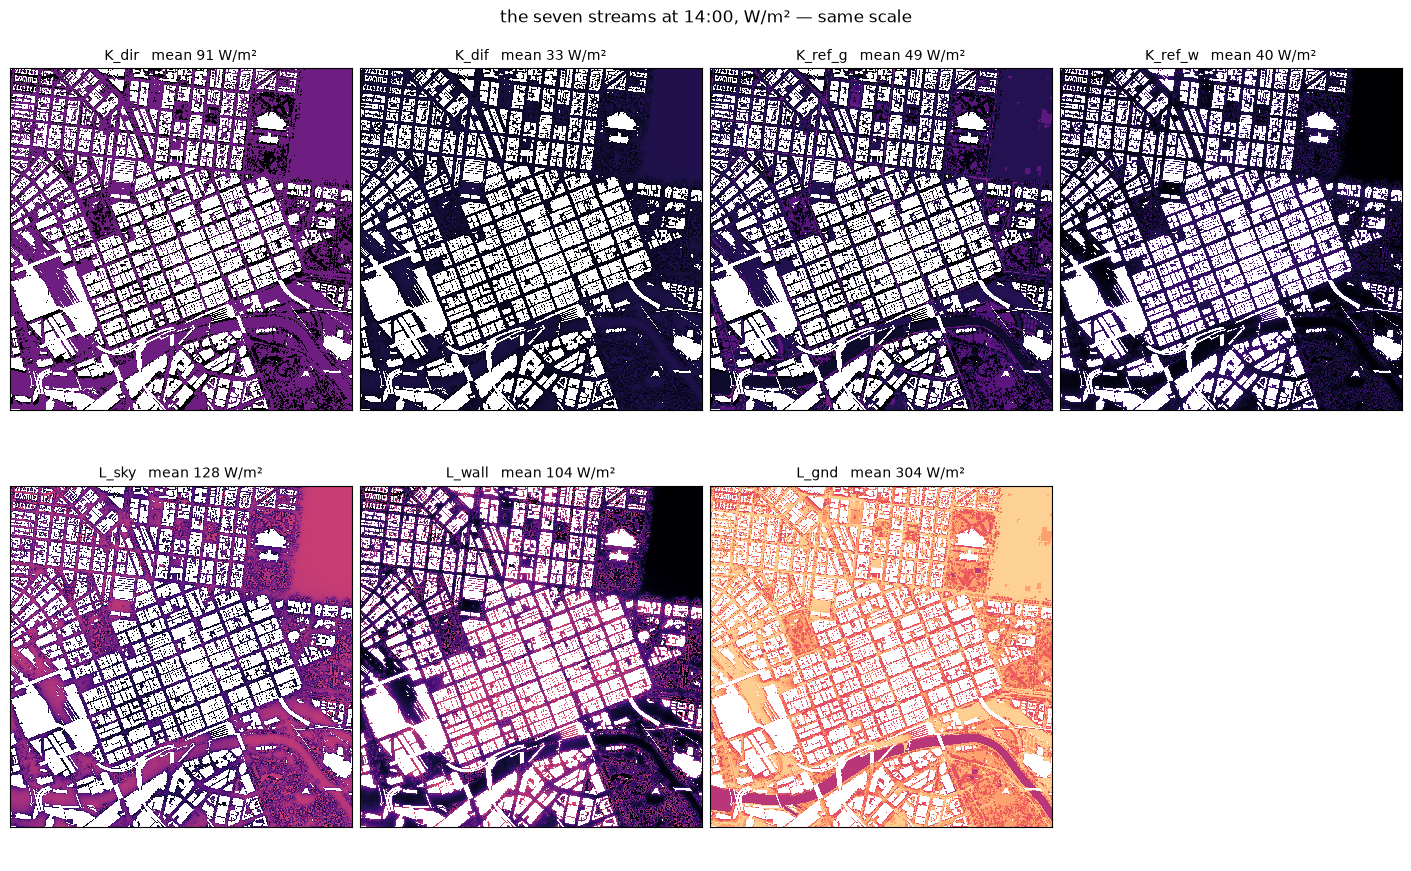

In [12]:
parts = [np.broadcast_to(p, svf.shape) for p in streams(HOUR, ~shade[HOUR], svf, mat, tsurf[HOUR])]

fig, axes = plt.subplots(2, 4, figsize=(14, 8.6), constrained_layout=True)
for ax, name, arr in zip(axes.ravel(), NAMES, parts):
    ax.imshow(np.ma.masked_where(~ground, arr), cmap="magma",
              vmin=0, vmax=400, interpolation="nearest")
    ax.set_title(f"{name}   mean {arr[ground].mean():.0f} W/m²", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

axes.ravel()[-1].axis("off")
fig.suptitle(f"the seven streams at {HOUR}:00, W/m² — same scale", fontsize=12)

## The map

Turbo, roofs greyed out. Everything the sun reaches is one colour and everything it does not is
another — buildings and trees cut their own shape out of the heat, and the laneways read as cool
channels through the middle of it.

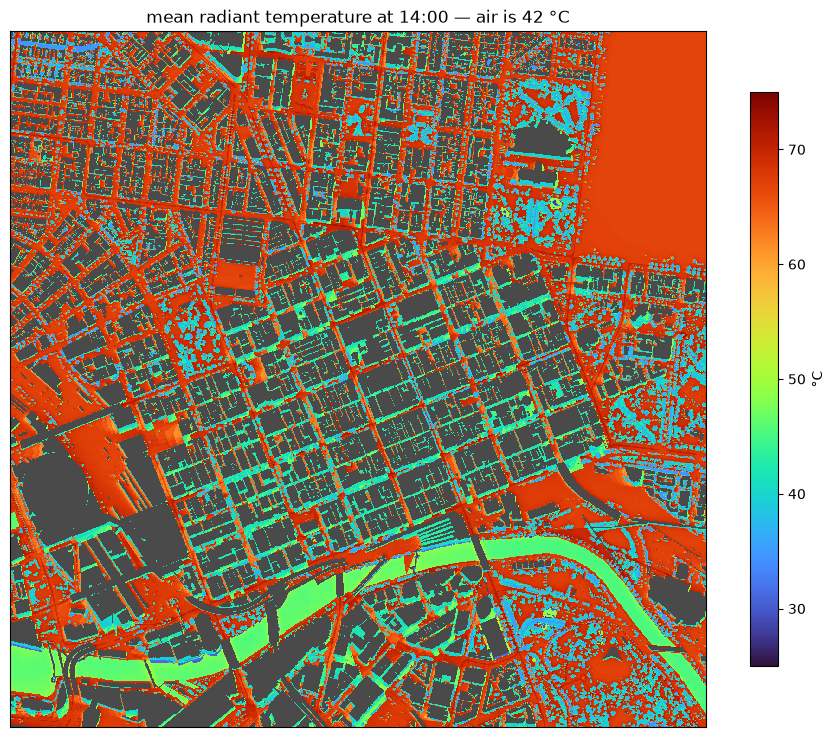

In [13]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.imshow(~ground, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(~ground, mrt_crop[HOUR]), cmap="turbo",
               vmin=25, vmax=75, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"mean radiant temperature at {HOUR}:00 — air is {w.loc[HOUR, 'temperature_2m']:.0f} °C")
fig.colorbar(im, ax=ax, shrink=0.7, label="°C")
fig.tight_layout()

### The same map, minus the air

Subtract air temperature and the map becomes a price list: red is what standing there costs you,
blue is what it saves, both in degrees.

There is almost no middle. Sunlit ground sits about +25, shade sits at or below zero, and the
thin band between them is the edge of a shadow. That is the whole finding — a pedestrian is not
choosing between warm and warmer, they are choosing between two piles 25 °C apart.

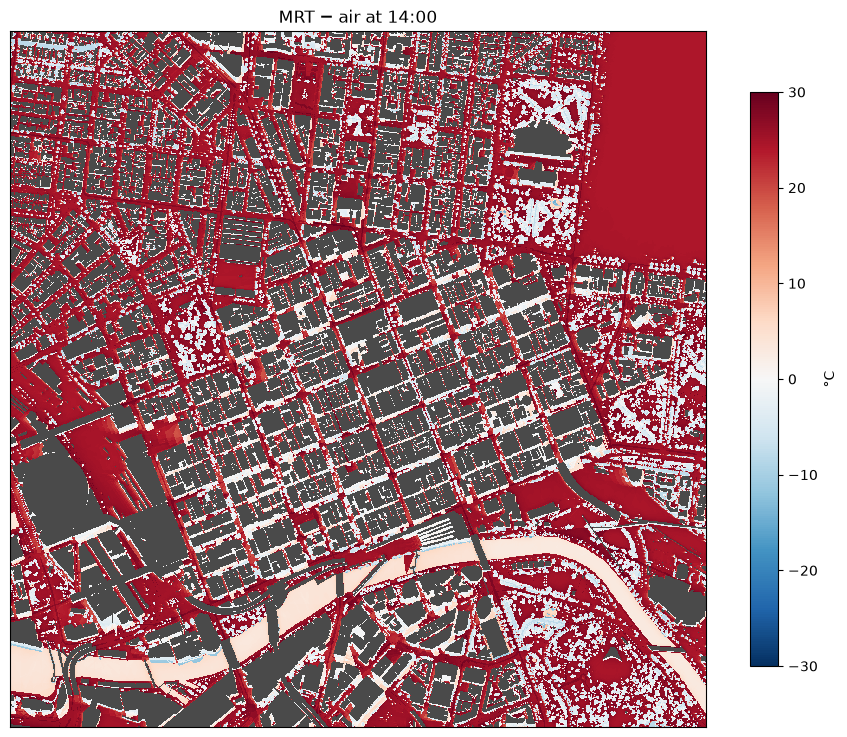

In [14]:
fig, ax = plt.subplots(figsize=(9, 8.5))
ax.imshow(~ground, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(~ground, mrt_crop[HOUR] - w.loc[HOUR, "temperature_2m"]),
               cmap="RdBu_r", vmin=-30, vmax=30, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"MRT − air at {HOUR}:00")
fig.colorbar(im, ax=ax, shrink=0.7, label="°C")
fig.tight_layout()

## The whole grid

08 needs the lot, so the same call runs over the full rasters and writes an hour per file.

In [15]:
svf_full = np.load("out/rasters/svf_veg.npy")
mat_full = np.load("out/rasters/material_id.npy")

for h in HOURS:
    shade_h = np.load(f"out/rasters/shade_{h:02d}.npy")
    tsurf_h = np.load(f"out/rasters/tsurf_{h:02d}.npy")
    np.save(f"out/rasters/mrt_{h:02d}.npy",
            mrt(h, ~shade_h, svf_full, mat_full, tsurf_h).astype(np.float32))

print(f"out/rasters/mrt_06.npy .. mrt_20.npy   {len(HOURS)} files at"
      f" {svf_full.shape[1]} x {svf_full.shape[0]}")

out/rasters/mrt_06.npy .. mrt_20.npy   15 files at 2438 x 2485


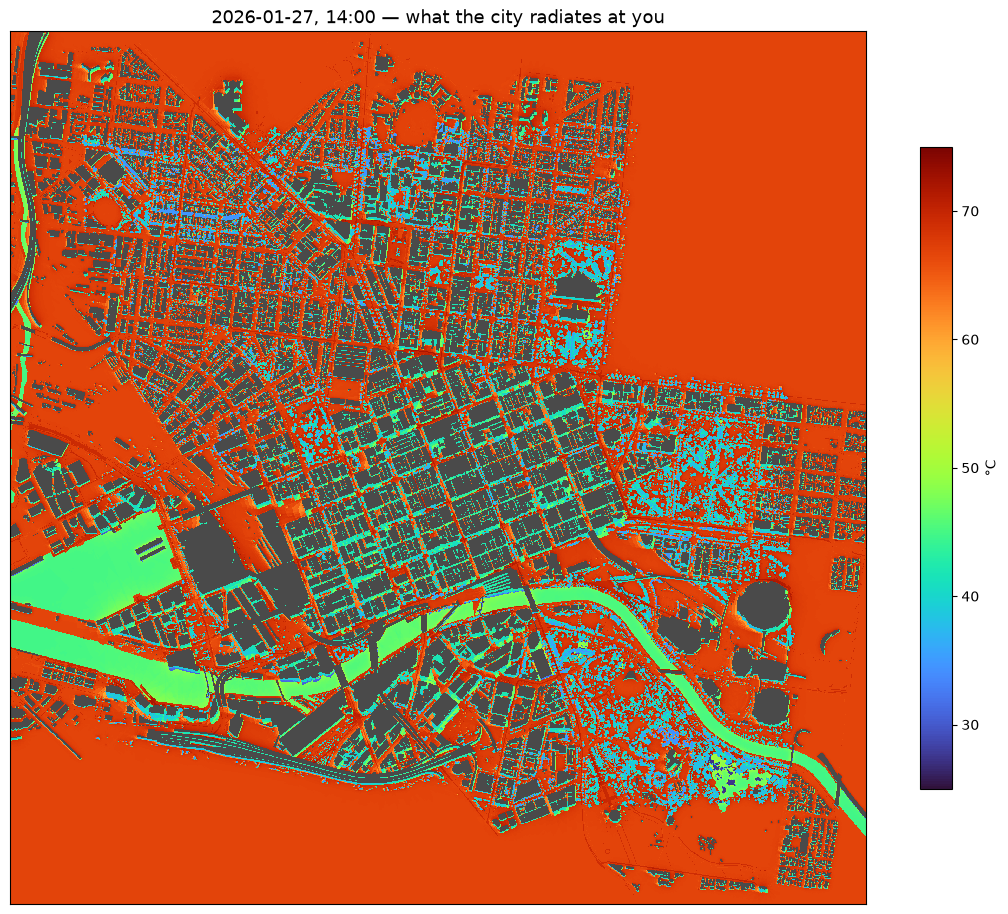

In [16]:
dsm_full = np.load("out/rasters/dsm_buildings.npy")
ground_full = dsm_full <= 0

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(~ground_full, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(~ground_full, np.load(f"out/rasters/mrt_{HOUR:02d}.npy")),
               cmap="turbo", vmin=25, vmax=75, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{DATE}, {HOUR}:00 — what the city radiates at you", fontsize=13)
fig.colorbar(im, ax=ax, shrink=0.6, label="°C")
fig.tight_layout()